In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy as sp
import scipy.ndimage
import json
import skimage.io

toppath = '/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem'
processing_dict_path = os.path.join(toppath, 'processing_data.json')

In [2]:
series = 'C'
sample = '4'

In [3]:
sample_path = os.path.join(toppath, series+'_series', series+'_'+sample)
stage = 'preop'

In [4]:
outputpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_rotcrop.tif')

In [5]:
im = skimage.io.imread(outputpath)

In [6]:
sample_path = os.path.join(toppath, series+'_series', series+'_'+sample)
stage = 'postop_2'

In [7]:
outputpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_rotcrop.tif')

In [8]:
im2 = skimage.io.imread(outputpath)

In [9]:
vmin = -0.0587
vmax = 0.3144

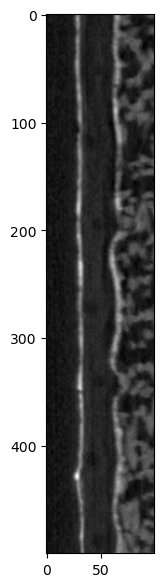

In [10]:
plt.figure(figsize=(12,7))
plt.imshow(im[300:800,250,:], 'gray')

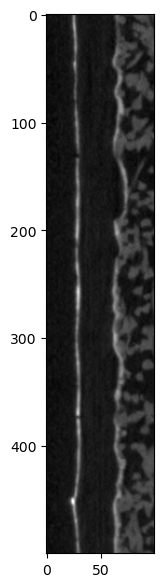

In [11]:
plt.figure(figsize=(12,7))
plt.imshow(im2[300:800,250,:], 'gray')

In [49]:
test = im[300:800,250,:].copy()

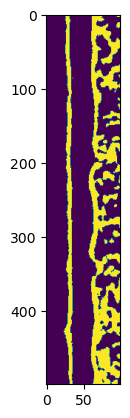

In [50]:
plt.imshow(test>0.3)

In [51]:
line = np.argmax(test>0.3, axis=1)

In [52]:
for i in range(len(line)):
    test[...,:line[i]+10] = 0

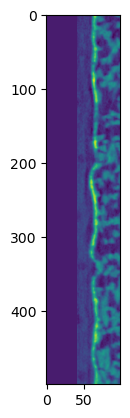

In [53]:
plt.imshow(test)

In [61]:
area = np.argmax(im>0.3, axis=2)

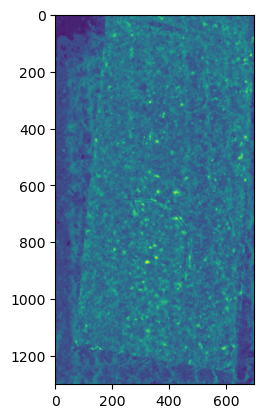

In [69]:
plt.imshow(im.max(axis=2))

In [65]:
area.mean()

31.91831208791209

In [66]:
line.mean()

28.726

In [67]:
np.median(area)

28.0

In [73]:
def crop_cathode_CL(im):
    area = np.argmax(im>0.3, axis=2)
    med = np.median(area).astype(int)
    for x in range(im.shape[0]):
        for y in range(im.shape[1]):
            crop = area[x,y]
            if np.abs(crop-med)>10:
                crop = med
            crop = crop+10
            im[x,y,:crop] = 0

    return im

In [74]:
cropped = crop_cathode_CL(im)

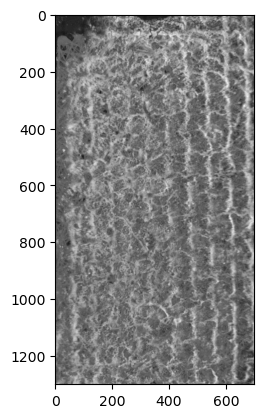

In [77]:
plt.imshow(cropped.max(axis=2), 'gray')

## Use CL as deliminators and cut a "isosurface" at the center through the membrane
find peaks, use neighbor position if not found 

In [11]:
import os
import skimage.io
import matplotlib.pyplot as plt

In [229]:
import matplotlib

In [234]:
from matplotlib import cm
from matplotlib.colors import Normalize

In [13]:
import scipy as sp
import scipy.signal

In [25]:
import numpy as np

In [96]:
import scipy.ndimage

In [482]:
im = skimage.io.imread('/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/C_series/C_2/C_2_postop_1_rotcrop.tif')

In [483]:
im = im[100:1100,50:550,:]

In [484]:
a = 400
b = 370

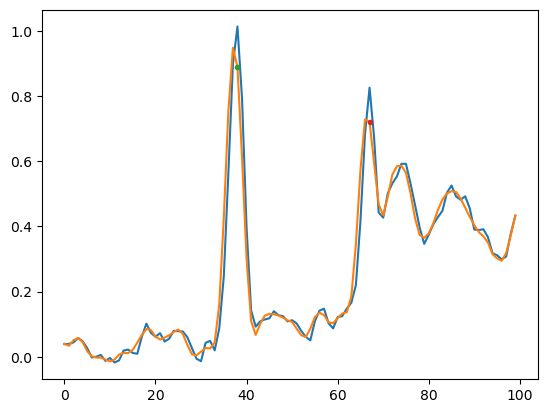

In [528]:
plt.plot(im[a,b,:])
plt.plot(test)
for (x,y) in zip(peaks, props['peak_heights']):
    y = test[x]
    plt.plot(x,y,'.')

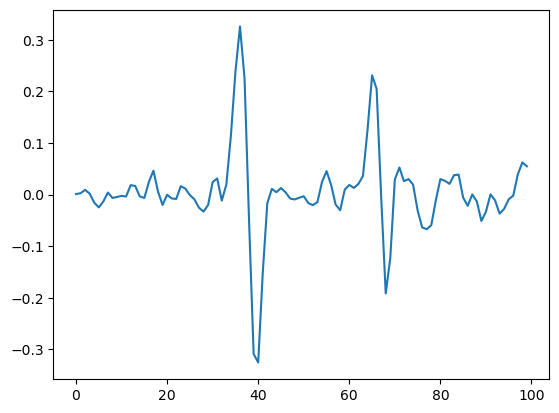

In [666]:
plt.plot(np.gradient(im[a,b,:]))

In [486]:
test = im[a,b,:].copy()
test = sp.signal.savgol_filter(test, 10, 5)

In [527]:
peaks, props = sp.signal.find_peaks(-np.gradient(np.gradient(im[a,b,:])), height=0.1, distance=15)

In [488]:
peaks[:2]

array([37, 66])

In [21]:
props

{'peak_heights': array([0.57733309, 0.6197108 ])}

In [391]:
vmin = 10
vmax = 80
cmap = cm.viridis

bounds = np.arange(vmin,vmax, 5)
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)

In [667]:
def search_crude_CL(im):
    med = np.median(im)
    shp = im.shape
    CL = np.zeros((shp[0],shp[1],2), dtype = int)
    grad = -np.gradient(np.gradient(im, axis=2), axis=2)
    # grad = np.gradient(im, axis=2)
    for x in range(shp[0]):
        for y in range(shp[1]):
            prof = grad[x,y,:]
            peaks, props = sp.signal.find_peaks(prof, height=6*med/8, distance=15, prominence=med/4)
            LP = len(peaks)
            if LP>0:
                peaks = peaks[:2]
                CL[x,y,-LP:] = peaks
    return CL    #, excess_peaks

In [702]:
def find_center_surface(CL):
    # some hard coded limits and median filtering
    
    CL0 = CL[:,:,0]
    CL1 = CL[:,:,1]

    #global median filter
    medCL0 = np.median(CL0[CL0>0])
    CL0[CL0<5] = medCL0

    medCL1 = np.median(CL1)
    CL1[CL1<medCL0+10] = medCL1

    # #local median filter
    CL0 = sp.ndimage.median_filter(CL0, size = 4)
    CL1 = sp.ndimage.median_filter(CL1, size = 4)
    
    diff = (CL1-CL0)/2
    meddiff = np.median(diff)
    diff[diff<10] = meddiff
    diff[diff>60]  = meddiff
    
    IFcoords = np.uint16(CL1-diff)

    # IFcoords = np.uint16((CL1+CL0)/2)
    coordmed = np.median(IFcoords)
    IFcoords[IFcoords>80] = coordmed
    IFcoords[IFcoords<30] = coordmed
    IFcoords = sp.ndimage.median_filter(IFcoords, size = 4)
    
    return IFcoords

def extract_center_face(im, IFcoords):

    shp = IFcoords.shape
    interface = np.zeros(shp)
    for x in range(shp[0]):
        for y in range(shp[1]):
            z = IFcoords[x,y]
            interface[x,y] = im[x,y,z]
            # interface[x,y] = im[x-fs:x+fs,y-fs:y+fs,z-fs:z+fs].mean()  #small mean filtering

    return interface

def cut_through_membrane_center(im):
    CL = search_crude_CL(im)
    IFcoords = find_center_surface(CL)
    interface = extract_center_face(im, IFcoords)
    return interface

In [703]:
CL = search_crude_CL(im)
IFcoords = find_center_surface(CL)
interface = extract_center_face(im, IFcoords)

(-0.5, 499.5, 999.5, -0.5)

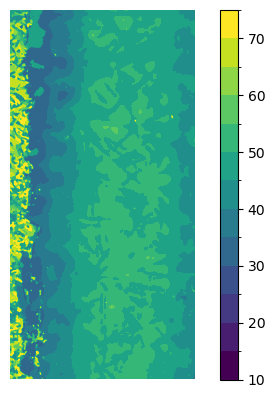

In [704]:
plt.imshow(IFcoords, cmap=cm.viridis, norm=norm)
plt.colorbar()
plt.axis('off')

(-0.5, 499.5, 999.5, -0.5)

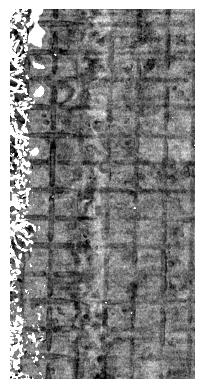

In [705]:
plt.imshow(interface, 'gray', vmin=0, vmax=0.2)
plt.axis('off')

(-0.5, 499.5, 999.5, -0.5)

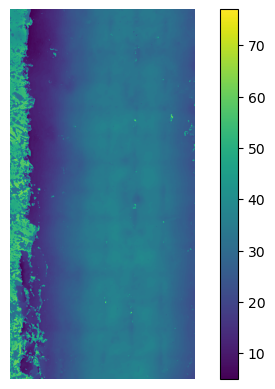

In [698]:
plt.imshow(CL[:,:,0])#, cmap=cm.viridis, norm=norm)
plt.colorbar()
plt.axis('off')

(-0.5, 499.5, 999.5, -0.5)

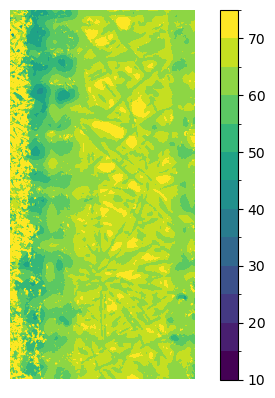

In [699]:
plt.imshow(CL[:,:,1], cmap=cm.viridis, norm=norm)
plt.colorbar()
plt.axis('off')

(-0.5, 499.5, 999.5, -0.5)

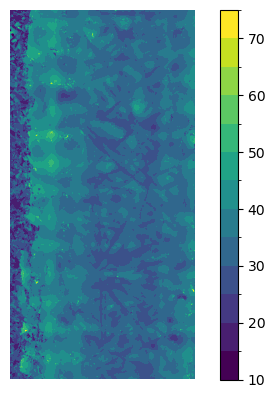

In [700]:
plt.imshow(CL[:,:,1]-CL[:,:,0], cmap=cm.viridis, norm=norm)
plt.colorbar()
plt.axis('off')

(-0.5, 499.5, 999.5, -0.5)

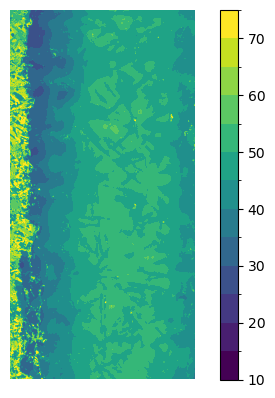

In [701]:
plt.imshow((CL[:,:,1]+CL[:,:,0])/2, cmap=cm.viridis, norm=norm)
plt.colorbar()
plt.axis('off')

In [8]:
ims = [im1, im2, im3, im4]

In [3]:
im1 = skimage.io.imread(os.path.join(toppath, 'C_series', 'C_2', 'C_2_postop_1_rotcrop.tif'))

In [4]:
im2 = skimage.io.imread(os.path.join(toppath, 'C_series', 'C_2', 'C_2_postop_2_rotcrop.tif'))

In [5]:
im3 = skimage.io.imread(os.path.join(toppath, 'A_series', 'A_12', 'A_12_postop_1_rotcrop.tif'))

In [6]:
im4 = skimage.io.imread(os.path.join(toppath, 'A_series', 'A_12', 'A_12_postop_2_rotcrop.tif'))

In [20]:
bins = np.arange(0, 2, 0.01)

In [21]:
hists = []
for im in ims:
    hist = np.histogram(im.max(axis=2).flatten(), bins=bins)
    hists.append(hist)

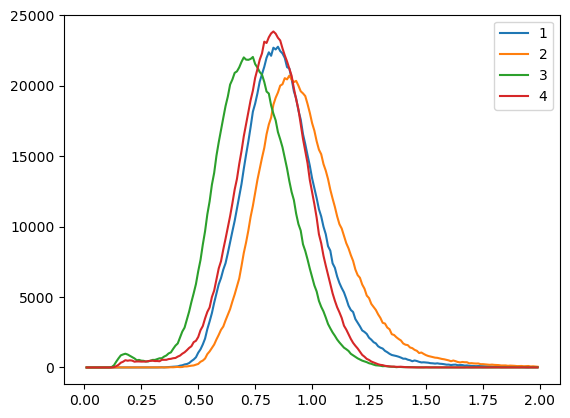

In [24]:
i = 1
for hist in hists:
    plt.plot(bins[1:], hist[0], label=i)
    i = i+1

plt.legend()

In [25]:
hists = []
for im in ims:
    hist = np.histogram(im.flatten(), bins=bins)
    hists.append(hist)

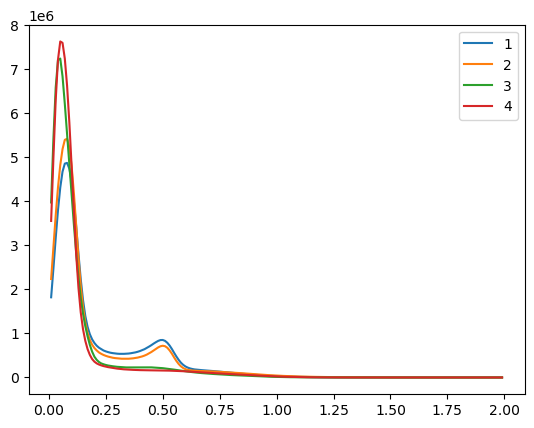

In [26]:
i = 1
for hist in hists:
    plt.plot(bins[1:], hist[0], label=i)
    i = i+1

plt.legend()